<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase%202/O3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

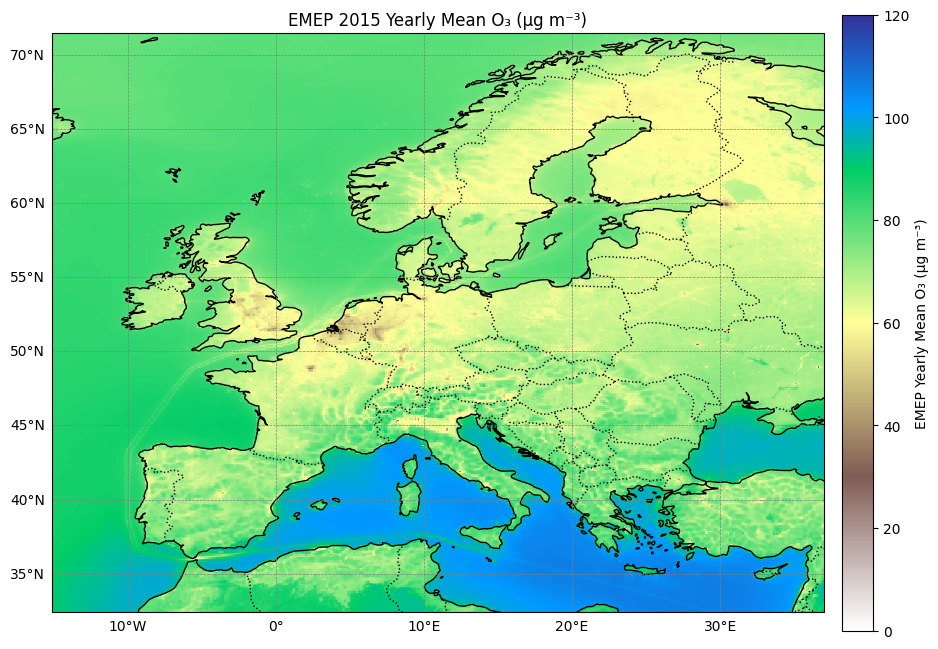

In [44]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP O₃ NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2015.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract O₃ values (μg m⁻³)
o3 = ds["SURF_ug_O3"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization ===
norm = mcolors.Normalize(0, 120)  # adjust if needed

# Create a figure with a map projection
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot the O₃ concentration using pcolormesh
mesh = ax.pcolormesh(
    Lon,
    Lat,
    o3,
    cmap='terrain_r',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean O₃ (μg m⁻³)")

# Add coastlines and borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Set labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2015 Yearly Mean O₃ (μg m⁻³)")

# Show plot
plt.show()

# Close dataset
ds.close()


In [28]:
import pandas as pd

# Load CSV
stations = pd.read_csv("yearly_O3_2015.csv")

# Remove southern outlier(s): Réunion
stations_clean = stations[stations["Latitude"] >= 0].copy()

# Sanity check
print("Original stations:", len(stations))
print("After removal:", len(stations_clean))
print("Latitude min:", stations_clean["Latitude"].min())

stations_clean.to_csv("yearly_O3_2015_NS.csv", index=False)

Original stations: 1754
After removal: 1747
Latitude min: 35.038


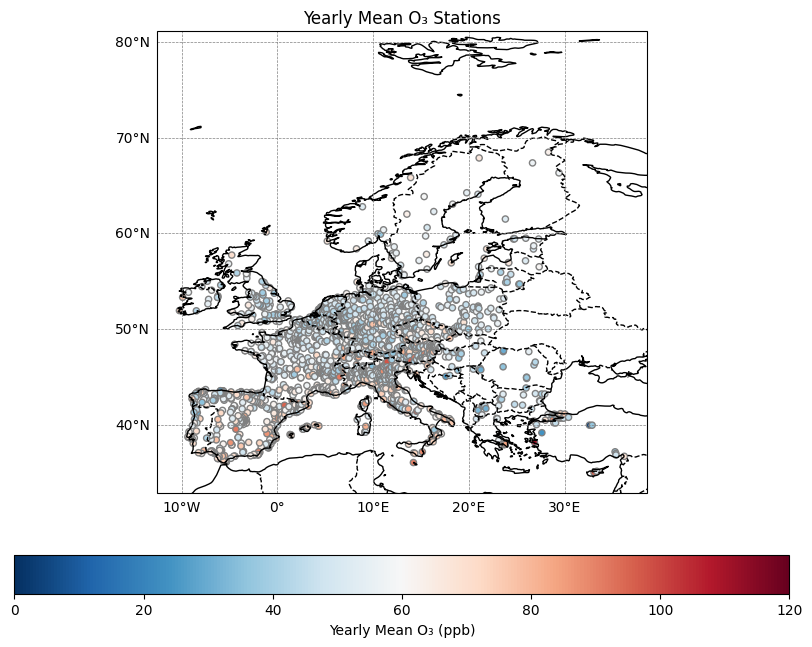

In [40]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Load cleaned station data
stations = pd.read_csv("yearly_O3_2015_NS.csv")

# Fixed colour scale (same philosophy as residuals)
cbar_min = 0
cbar_max = 120

# Create map
fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Scatter plot (same style)
sc = ax.scatter(
    stations["Longitude"],
    stations["Latitude"],
    c=stations["Average"],
    cmap="RdBu_r",
    vmin=cbar_min,
    vmax=cbar_max,
    edgecolors="grey",
    s=20,
    transform=ccrs.PlateCarree()
)

# Horizontal colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.1)
cbar.set_label("Yearly Mean O₃ (μg m⁻³)")

# Title
ax.set_title("Yearly Mean O₃ Stations")

plt.show()


In [48]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# Input files
nc_file_path = "EMEP_yearly_2015.nc"
csv_file_path = "yearly_O3_2015_NS.csv"

# Load EMEP NetCDF (model data)
ds = xr.open_dataset(nc_file_path).squeeze()

lon_values = ds["lon"].values
lat_values = ds["lat"].values
o3_grid = ds["SURF_ug_O3"].values   # μg m⁻³

# Create grid points (lat, lon)
lon_grid, lat_grid = np.meshgrid(lon_values, lat_values)

grid_points_deg = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
grid_points_rad = np.radians(grid_points_deg)

o3_values = o3_grid.ravel()


# Load station data (observations)
station_data = pd.read_csv(csv_file_path)

station_lons = station_data["Longitude"].values
station_lats = station_data["Latitude"].values
station_observed_o3 = station_data["Average"].values   # μg m⁻³

station_coords_deg = np.column_stack((station_lats, station_lons))
station_coords_rad = np.radians(station_coords_deg)

# Nearest grid cell matching (Haversine)
tree = BallTree(grid_points_rad, metric="haversine")

distances_rad, indices = tree.query(station_coords_rad, k=1)
nearest_indices = indices.flatten()

nearest_grid_coords = grid_points_deg[nearest_indices]  # (lat, lon)
nearest_o3_values = o3_values[nearest_indices]

# Create output DataFrame
grid_cell_indices = list(
    zip(nearest_grid_coords[:, 1], nearest_grid_coords[:, 0])
)  # (lon, lat)

df_matched = pd.DataFrame({
    "lon": station_lons,
    "lat": station_lats,
    "nearest_grid_lon": nearest_grid_coords[:, 1],
    "nearest_grid_lat": nearest_grid_coords[:, 0],
    "grid_cell_index": grid_cell_indices,
    "SURF_ug_O3": station_observed_o3,
    "nearest_SURF_ug_O3": nearest_o3_values
})

df_matched = df_matched[
    [
        "lon",
        "lat",
        "nearest_grid_lon",
        "nearest_grid_lat",
        "grid_cell_index",
        "SURF_ug_O3",
        "nearest_SURF_ug_O3",
    ]
]

# Save output
output_csv = "EMEP2015_nearest_station_match_ug.csv"
df_matched.to_csv(output_csv, index=False)

print(f"Done. File saved as '{output_csv}'")

# Close dataset
ds.close()

Done. File saved as 'EMEP2015_nearest_station_match_ug.csv'


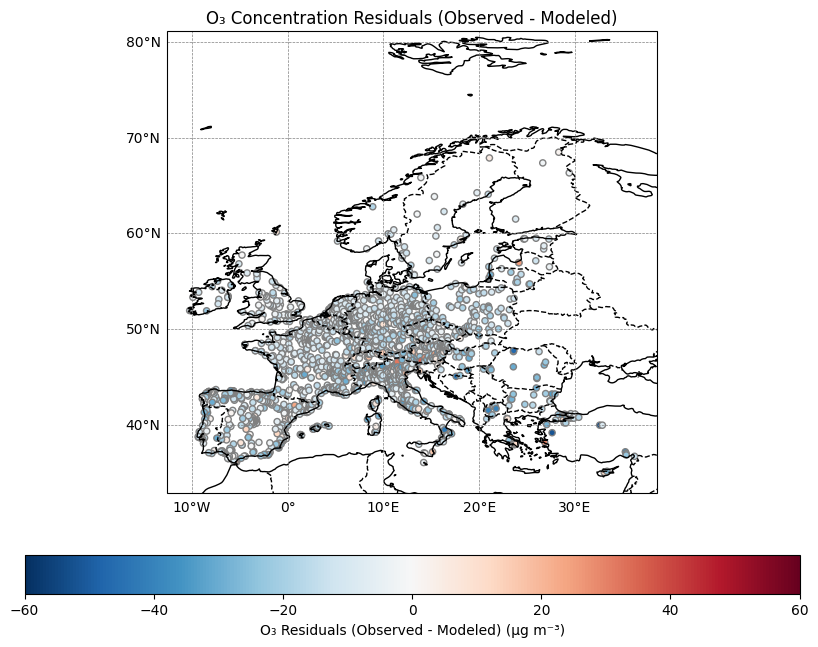

In [54]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Φόρτωση των δεδομένων
stations = pd.read_csv("EMEP2015_nearest_station_match_ug.csv")

# Υπολογισμός των residuals ως (Observed - Modeled)
stations["O3_residuals"] = stations["SURF_ug_O3"] - stations["nearest_SURF_ug_O3"]

# Ορισμός των ορίων της χρωματικής κλίμακας
cbar_min = -60
cbar_max = 60

# Δημιουργία χάρτη
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Προσθήκη συνόρων και ακτογραμμών
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Προσθήκη γραμμών πλέγματος
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Αφαίρεση ετικετών στην κορυφή
gl.right_labels = False  # Αφαίρεση ετικετών στα δεξιά

# Προβολή των residuals O₃ με χρωματική κλίμακα RdBu (το 0 στο λευκό)
sc = ax.scatter(
    stations["lon"],
    stations["lat"],
    c=stations["O3_residuals"],
    cmap="RdBu_r",
    vmin=cbar_min,
    vmax=cbar_max,
    edgecolors="grey",
    s=20,
    transform=ccrs.PlateCarree()
)

# Προσθήκη οριζόντιας χρωματικής κλίμακας κάτω από το σχήμα
cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.1)
cbar.set_label("O₃ Residuals (Observed - Modeled) (μg m⁻³)")

# Τίτλος
ax.set_title("O₃ Concentration Residuals (Observed - Modeled)")

# Εμφάνιση χάρτη
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from matplotlib.lines import Line2D

# Φόρτωση των δεδομένων
stations = pd.read_csv("baseO3nearest_grid.csv")

# Υπολογισμός των residuals ως (Observed - Modeled)
stations["O3_residuals"] = stations["SURF_ppb_O3"] - stations["nearest_SURF_ppb_O3"]

# Ορισμός χρώματος ανάλογα με το πρόσημο των residuals
colors = stations["O3_residuals"].apply(lambda x: "red" if x > 0 else "blue")

# Δημιουργία χάρτη
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Προσθήκη συνόρων και ακτογραμμών
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Προσθήκη γραμμών πλέγματος
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Αφαίρεση ετικετών στην κορυφή
gl.right_labels = False  # Αφαίρεση ετικετών στα δεξιά

# Προβολή των residuals O₃ με δύο χρώματα (κόκκινο = Observed > Modeled, μπλε = Observed < Modeled)
sc = ax.scatter(
    stations["lon"],
    stations["lat"],
    c=colors,
    edgecolors=None,
    s=5,  # Σταθερό μέγεθος σημείων
    transform=ccrs.PlateCarree()
)

# Προσθήκη υπομνήματος
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label="Observed > Modeled"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label="Observed < Modeled")
]
ax.legend(handles=legend_elements, loc="upper left")

# Τίτλος
ax.set_title("O₃ Concentration Residuals (Observed - Modeled)")

# Εμφάνιση χάρτη
plt.show()

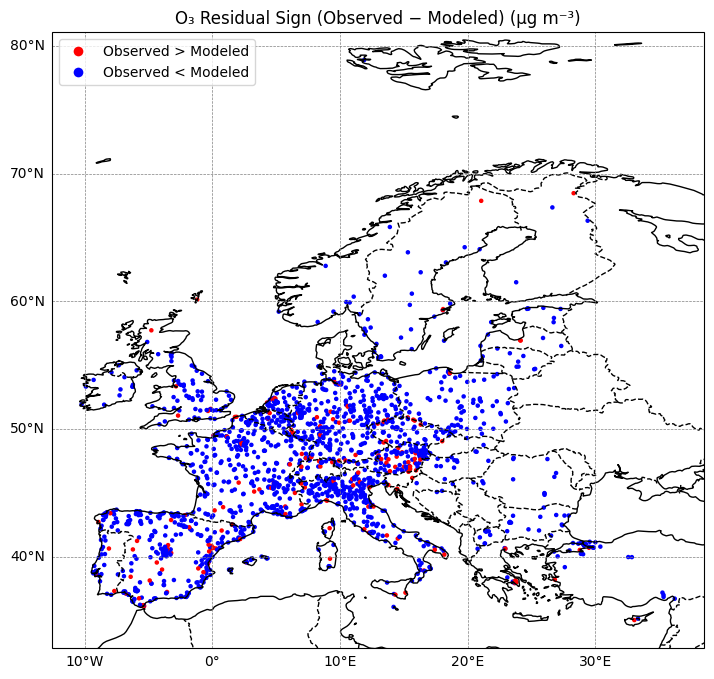

In [55]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from matplotlib.lines import Line2D

# Load matched station–EMEP data (μg m⁻³)
stations = pd.read_csv("EMEP2015_nearest_station_match_ug.csv")

# Compute residuals (Observed - Modeled)
stations["O3_residuals"] = (
    stations["SURF_ug_O3"] - stations["nearest_SURF_ug_O3"]
)

# Assign color based on residual sign
colors = stations["O3_residuals"].apply(
    lambda x: "red" if x > 0 else "blue"
)

# Create map
fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Scatter plot (sign only)
ax.scatter(
    stations["lon"],
    stations["lat"],
    c=colors,
    s=5,
    transform=ccrs.PlateCarree()
)

# Legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="red", markersize=8,
           label="Observed > Modeled"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="blue", markersize=8,
           label="Observed < Modeled"),
]
ax.legend(handles=legend_elements, loc="upper left")

# Title
ax.set_title("O₃ Residual Sign (Observed − Modeled) (μg m⁻³)")

plt.show()
